In [25]:
import pandas as pd
import numpy as np

# 데이터 불러오기
df = pd.read_csv("Sleep Health and Lifestyle Dataset.csv")

print("데이터 크기:", df.shape)
df.head()

데이터 크기: (30000, 39)


,Patient_ID,Age,Gender,Occupation,Marital_Status,Physical_Activity_Minutes,Screen_Time_Hours,Daily_Steps,Water_Intake_Liters,Caffeine_Intake_mg,...,Depression_Score,Workload_Score,Snoring_Frequency,Respiratory_Disturbance_Index,Leg_Movement_Index,Sleep_Risk_Index,Lifestyle_Risk_Index,Physiological_Risk_Index,Mental_Health_Risk_Index,Sleep_Disorder
0,1,49,Female,Engineer,Married,38.7,3.2,3666,2.90,148,...,6,7,8,33.6,12.4,4.48,2.46,15.59,6.0,Sleep Apnea
1,2,40,Female,Student,Married,55.9,8.2,6239,2.65,138,...,2,3,2,2.8,14.1,2.22,4.52,6.34,6.5,No Disorder
2,3,42,Female,Doctor,Married,53.3,3.9,6932,2.67,195,...,1,4,2,4.1,5.5,2.07,3.00,6.56,6.5,No Disorder
3,4,51,Male,Engineer,Married,47.6,7.1,6036,1.88,183,...,2,6,2,7.6,8.6,1.90,4.60,5.66,6.5,No Disorder
4,5,44,Female,Analyst,Single,87.1,6.3,11413,2.49,205,...,4,5,2,0.0,7.4,2.15,3.74,5.08,6.0,No Disorder


In [26]:
# 생활습관 위험 지수 예측에 사용할 사용자 입력값
model2_features = [
    "Age",
    "Gender",
    "BMI",
    "Sleep_Duration",
    "Screen_Time_Hours",
    "Caffeine_Intake_mg",
    "Stress_Level",
    "Alcohol_Consumption",
    "Physical_Activity_Minutes",
    "Smoking_Status"
]

# 예측 대상
target = "Lifestyle_Risk_Index"

# 모델링에 사용할 데이터 구성
model2_df = df[model2_features + [target]].copy()

print("=== Feature ===")
print(model2_features)

print("\n=== Target ===")
print(target)

print("\n=== 데이터 크기 ===")
print(model2_df.shape)

print("\n=== 결측치 ===")
print(model2_df.isnull().sum())

print("\n=== Target 통계 ===")
print(model2_df[target].describe())

=== Feature ===
['Age', 'Gender', 'BMI', 'Sleep_Duration', 'Screen_Time_Hours', 'Caffeine_Intake_mg', 'Stress_Level', 'Alcohol_Consumption', 'Physical_Activity_Minutes', 'Smoking_Status']

=== Target ===
Lifestyle_Risk_Index

=== 데이터 크기 ===
(30000, 11)

=== 결측치 ===
Age                          0
Gender                       0
BMI                          0
Sleep_Duration               0
Screen_Time_Hours            0
Caffeine_Intake_mg           0
Stress_Level                 0
Alcohol_Consumption          0
Physical_Activity_Minutes    0
Smoking_Status               0
Lifestyle_Risk_Index         0
dtype: int64

=== Target 통계 ===
count    30000.000000
mean         3.961142
std          1.314439
min         -1.090000
25%          3.070000
50%          3.960000
75%          4.860000
max          9.020000
Name: Lifestyle_Risk_Index, dtype: float64


In [27]:
print("=== 데이터 타입 ===")
print(model2_df.dtypes)

print("\n=== 숫자형 변수 기술통계 ===")
print(
    model2_df
    .select_dtypes(include="number")
    .describe()
)

=== 데이터 타입 ===
Age                            int64
Gender                           str
BMI                          float64
Sleep_Duration               float64
Screen_Time_Hours            float64
Caffeine_Intake_mg             int64
Stress_Level                   int64
Alcohol_Consumption              str
Physical_Activity_Minutes    float64
Smoking_Status                   str
Lifestyle_Risk_Index         float64
dtype: object

=== 숫자형 변수 기술통계 ===
                Age           BMI  Sleep_Duration  Screen_Time_Hours  \
count  30000.000000  30000.000000    30000.000000       30000.000000   
mean      41.589133     25.978760        6.321516           5.990400   
std       11.716596      4.108634        1.180074           1.996297   
min       18.000000     18.000000        2.500000           1.000000   
25%       33.000000     23.200000        5.447500           4.600000   
50%       41.000000     25.500000        6.370000           6.000000   
75%       50.000000     28.300000      

In [28]:
categorical_features = [
    "Gender",
    "Alcohol_Consumption",
    "Smoking_Status"
]

print("\n=== 범주형 변수 고유값 ===")

for column in categorical_features:
    print(f"{column}: {model2_df[column].unique()}")

print("\n=== Stress_Level 분포 ===")
print(
    model2_df["Stress_Level"]
    .value_counts()
    .sort_index()
)


=== 범주형 변수 고유값 ===
Gender: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
Alcohol_Consumption: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Smoking_Status: <StringArray>
['Yes', 'No']
Length: 2, dtype: str

=== Stress_Level 분포 ===
Stress_Level
4    12026
7    11207
9     6767
Name: count, dtype: int64


In [29]:
# 숫자형 입력값과 Target(Lifestyle_Risk_Index) 간의 상관관계를 확인함.
#
# 각 입력값이 Lifestyle_Risk_Index와 어느 정도의 선형 관계를
# 가지는지 확인하여 모델 학습에 사용되는 입력값의 특성을 파악함.

numeric_features = [
    "Age",
    "BMI",
    "Sleep_Duration",
    "Screen_Time_Hours",
    "Caffeine_Intake_mg",
    "Stress_Level",
    "Physical_Activity_Minutes"
]

correlation = (
    model2_df[numeric_features + ["Lifestyle_Risk_Index"]]
    .corr()["Lifestyle_Risk_Index"]
    .sort_values(ascending=False)
)

print("=== Lifestyle_Risk_Index 상관관계 ===")
print(correlation)

=== Lifestyle_Risk_Index 상관관계 ===
Lifestyle_Risk_Index         1.000000
Screen_Time_Hours            0.758687
Caffeine_Intake_mg           0.599658
Age                          0.005379
Sleep_Duration               0.004684
BMI                          0.001598
Stress_Level                -0.005662
Physical_Activity_Minutes   -0.254975
Name: Lifestyle_Risk_Index, dtype: float64


In [30]:
# 전처리 담당자(영택님)가 생성한 상관관계 반영 버전의
# 전처리 결과를 불러와 모델 학습에 사용함.
#
# 동일한 전처리를 다시 수행하지 않고,
# 팀에서 공통으로 생성한 Train/Test 데이터와
# 전처리 객체를 사용하여 모델링 과정의 일관성을 유지함.
import joblib

# 전처리 담당자가 생성한 전처리 결과 불러오기
preprocessing_data = joblib.load(
    "sleep_preprocessing_yt_상관관계 반영ver.pkl"
)

print("=== PKL 데이터 타입 ===")
print(type(preprocessing_data))

# dictionary 형태인 경우 저장된 항목 확인
if isinstance(preprocessing_data, dict):
    print("\n=== 저장된 항목 ===")
    for key in preprocessing_data.keys():
        print(key)

=== PKL 데이터 타입 ===
<class 'dict'>

=== 저장된 항목 ===
X_train
X_test
y_train
y_test
scaler
encoder
numeric_features
categorical_features
outlier_bounds


In [31]:
# 전처리 결과 분리

X_train = preprocessing_data["X_train"]
X_test = preprocessing_data["X_test"]
y_train = preprocessing_data["y_train"]
y_test = preprocessing_data["y_test"]

scaler = preprocessing_data["scaler"]
encoder = preprocessing_data["encoder"]

numeric_features = preprocessing_data["numeric_features"]
categorical_features = preprocessing_data["categorical_features"]
outlier_bounds = preprocessing_data["outlier_bounds"]

print("=== 데이터 크기 ===")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\n=== 숫자형 Feature ===")
print(numeric_features)

print("\n=== 범주형 Feature ===")
print(categorical_features)

print("\n=== 이상치 처리 기준 ===")
print(outlier_bounds)

=== 데이터 크기 ===
X_train: (24000, 15)
X_test : (6000, 15)
y_train: (24000,)
y_test : (6000,)

=== 숫자형 Feature ===
['Age', 'BMI', 'Sleep_Duration', 'Screen_Time_Hours', 'Caffeine_Intake_mg', 'Physical_Activity_Minutes']

=== 범주형 Feature ===
['Gender', 'Stress_Level', 'Alcohol_Consumption', 'Smoking_Status']

=== 이상치 처리 기준 ===
{'Caffeine_Intake_mg': (0, np.float64(395.0)), 'Physical_Activity_Minutes': (0, np.float64(104.4))}


In [32]:
print("=== y_train 통계 ===")
print(y_train.describe())

print("\n=== y_test 통계 ===")
print(y_test.describe())

=== y_train 통계 ===
count    24000.000000
mean         3.960538
std          1.314968
min         -1.090000
25%          3.070000
50%          3.960000
75%          4.850000
max          9.020000
Name: Lifestyle_Risk_Index, dtype: float64

=== y_test 통계 ===
count    6000.000000
mean        3.963555
std         1.312428
min        -0.890000
25%         3.070000
50%         3.950000
75%         4.860000
max         8.380000
Name: Lifestyle_Risk_Index, dtype: float64


In [33]:
# Random Forest Baseline
#
# 전처리가 완료된 데이터를 이용하여 Lifestyle_Risk_Index를 예측함.
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

rf_model = RandomForestRegressor(
    random_state=42
)

# 모델 학습
rf_model.fit(X_train, y_train)

# Train / Test 예측
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

# Train 성능
rf_train_mae = mean_absolute_error(
    y_train, y_train_pred_rf
)

rf_train_rmse = np.sqrt(
    mean_squared_error(y_train, y_train_pred_rf)
)

rf_train_r2 = r2_score(
    y_train, y_train_pred_rf
)

# Test 성능
rf_test_mae = mean_absolute_error(
    y_test, y_test_pred_rf
)

rf_test_rmse = np.sqrt(
    mean_squared_error(y_test, y_test_pred_rf)
)

rf_test_r2 = r2_score(
    y_test, y_test_pred_rf
)

print("=== Random Forest Baseline Train ===")
print(f"MAE  : {rf_train_mae:.4f}")
print(f"RMSE : {rf_train_rmse:.4f}")
print(f"R²   : {rf_train_r2:.4f}")

print("\n=== Random Forest Baseline Test ===")
print(f"MAE  : {rf_test_mae:.4f}")
print(f"RMSE : {rf_test_rmse:.4f}")
print(f"R²   : {rf_test_r2:.4f}")

=== Random Forest Baseline Train ===
MAE  : 0.0155
RMSE : 0.0245
R²   : 0.9997

=== Random Forest Baseline Test ===
MAE  : 0.0408
RMSE : 0.0665
R²   : 0.9974


In [34]:
# 전처리 후 Feature 이름 확인
encoded_feature_names = encoder.get_feature_names_out(
    categorical_features
)

final_feature_names = (
    numeric_features
    + encoded_feature_names.tolist()
)

print("=== 최종 Feature ===")

for i, feature in enumerate(final_feature_names, start=1):
    print(f"{i}. {feature}")

print("\n최종 Feature 수:", len(final_feature_names))

=== 최종 Feature ===
1. Age
2. BMI
3. Sleep_Duration
4. Screen_Time_Hours
5. Caffeine_Intake_mg
6. Physical_Activity_Minutes
7. Gender_Female
8. Gender_Male
9. Stress_Level_High
10. Stress_Level_Low
11. Stress_Level_Medium
12. Alcohol_Consumption_No
13. Alcohol_Consumption_Yes
14. Smoking_Status_No
15. Smoking_Status_Yes

최종 Feature 수: 15


---
Random Forest Baseline 결과

Test MAE는 0.0408로 실제 Lifestyle_Risk_Index와 예측값 사이에
평균적으로 약 0.04의 절대 오차가 발생함.

Test RMSE는 0.0665이며,
Test R²는 0.9974로 매우 높은 예측 성능을 보임.

Train과 Test 모두 높은 성능을 보였으며,
Train 성능이 Test 성능보다 높지만 Test에서도 R²가 0.99 이상으로
유지되어 높은 일반화 성능을 확인함.

Feature Importance 분석 결과 Screen_Time_Hours,
Caffeine_Intake_mg, Physical_Activity_Minutes가
예측에 가장 큰 영향을 미치는 것으로 나타남.

---

In [35]:
# Linear Regression
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

# 모델 학습
linear_model.fit(
    X_train,
    y_train
)

# Train / Test 예측
y_train_pred_linear = linear_model.predict(X_train)
y_test_pred_linear = linear_model.predict(X_test)

# Train 성능
linear_train_mae = mean_absolute_error(
    y_train,
    y_train_pred_linear
)

linear_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        y_train_pred_linear
    )
)

linear_train_r2 = r2_score(
    y_train,
    y_train_pred_linear
)

# Test 성능
linear_test_mae = mean_absolute_error(
    y_test,
    y_test_pred_linear
)

linear_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred_linear
    )
)

linear_test_r2 = r2_score(
    y_test,
    y_test_pred_linear
)

print("=== Linear Regression Train ===")
print(f"MAE  : {linear_train_mae:.4f}")
print(f"RMSE : {linear_train_rmse:.4f}")
print(f"R²   : {linear_train_r2:.4f}")

print("\n=== Linear Regression Test ===")
print(f"MAE  : {linear_test_mae:.4f}")
print(f"RMSE : {linear_test_rmse:.4f}")
print(f"R²   : {linear_test_r2:.4f}")

=== Linear Regression Train ===
MAE  : 0.0138
RMSE : 0.0246
R²   : 0.9997

=== Linear Regression Test ===
MAE  : 0.0138
RMSE : 0.0272
R²   : 0.9996


---
Linear Regression 결과

Test MAE는 0.0138로 실제 Lifestyle_Risk_Index와 예측값 사이에
평균적으로 약 0.014의 절대 오차가 발생함.

Test RMSE는 0.0272이며,
Test R²는 0.9996으로 매우 높은 예측 성능을 보임.

Train과 Test의 MAE 및 R²가 거의 동일하게 나타나
학습 데이터와 테스트 데이터에서 안정적인 성능을 보임.

Random Forest Baseline과 비교했을 때
Linear Regression이 더 낮은 Test MAE와 RMSE,
더 높은 Test R²를 기록함.

따라서 현재 데이터에서는 복잡한 비선형 모델보다
단순한 선형 모델만으로도 Lifestyle_Risk_Index를
매우 높은 수준으로 예측할 수 있음을 확인함.

---

In [36]:
# Gradient Boosting

# Random Forest와 다른 방식의 트리 기반 앙상블 모델을 적용하여
# Lifestyle_Risk_Index 예측 성능을 비교하기 위해 선정함.
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    random_state=42
)

# 모델 학습
gb_model.fit(
    X_train,
    y_train
)

# Train / Test 예측
y_train_pred_gb = gb_model.predict(X_train)
y_test_pred_gb = gb_model.predict(X_test)

# Train 성능
gb_train_mae = mean_absolute_error(
    y_train,
    y_train_pred_gb
)

gb_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        y_train_pred_gb
    )
)

gb_train_r2 = r2_score(
    y_train,
    y_train_pred_gb
)

# Test 성능
gb_test_mae = mean_absolute_error(
    y_test,
    y_test_pred_gb
)

gb_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred_gb
    )
)

gb_test_r2 = r2_score(
    y_test,
    y_test_pred_gb
)

print("=== Gradient Boosting Train ===")
print(f"MAE  : {gb_train_mae:.4f}")
print(f"RMSE : {gb_train_rmse:.4f}")
print(f"R²   : {gb_train_r2:.4f}")

print("\n=== Gradient Boosting Test ===")
print(f"MAE  : {gb_test_mae:.4f}")
print(f"RMSE : {gb_test_rmse:.4f}")
print(f"R²   : {gb_test_r2:.4f}")

=== Gradient Boosting Train ===
MAE  : 0.0449
RMSE : 0.0575
R²   : 0.9981

=== Gradient Boosting Test ===
MAE  : 0.0472
RMSE : 0.0615
R²   : 0.9978


---

Gradient Boosting 결과

Test MAE는 0.0472로 실제 Lifestyle_Risk_Index와 예측값 사이에
평균적으로 약 0.047의 절대 오차가 발생함.

Test RMSE는 0.0615이며,
Test R²는 0.9978로 매우 높은 예측 성능을 보임.

Train과 Test의 성능 차이가 크지 않아
테스트 데이터에서도 안정적인 성능을 보임.

다만 Linear Regression과 비교했을 때
Test MAE와 RMSE가 더 높고 R²가 낮게 나타남.

---

In [37]:
# 세 회귀 모델의 Test 성능을 동일한 평가 지표로 비교함.
#
# MAE와 RMSE는 낮을수록 예측 오차가 작으며,
# R²는 1에 가까울수록 Target의 변동을 잘 설명하는 모델로 평가함.
#
# 모델의 성능뿐만 아니라 구조의 복잡도와 일반화 성능을 함께 고려하여
# 최종 모델을 선정함.

model_comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Linear Regression",
        "Gradient Boosting"
    ],
    "Train MAE": [
        rf_train_mae,
        linear_train_mae,
        gb_train_mae
    ],
    "Test MAE": [
        rf_test_mae,
        linear_test_mae,
        gb_test_mae
    ],
    "Test RMSE": [
        rf_test_rmse,
        linear_test_rmse,
        gb_test_rmse
    ],
    "Test R²": [
        rf_test_r2,
        linear_test_r2,
        gb_test_r2
    ]
})

model_comparison = (
    model_comparison
    .sort_values("Test MAE")
    .reset_index(drop=True)
)

print("=== 모델 성능 비교 ===")
print(model_comparison.round(4))

=== 모델 성능 비교 ===
               Model  Train MAE  Test MAE  Test RMSE  Test R²
0  Linear Regression     0.0138    0.0138     0.0272   0.9996
1      Random Forest     0.0155    0.0408     0.0665   0.9974
2  Gradient Boosting     0.0449    0.0472     0.0615   0.9978


최종 모델 선정

Random Forest, Linear Regression, Gradient Boosting을 동일한
Train/Test 데이터와 평가 지표를 사용하여 비교함.

세 모델 모두 높은 예측 성능을 보였으나,
Linear Regression이 가장 낮은 Test MAE와 RMSE,
가장 높은 Test R²를 기록함.

또한 Linear Regression은 Train MAE와 Test MAE가 거의 동일하여
새로운 데이터에서도 안정적인 일반화 성능을 보였음.

상관관계 분석에서도 Screen_Time_Hours와 Caffeine_Intake_mg 등
주요 입력값이 Lifestyle_Risk_Index와 높은 선형 관계를 보였으며,
복잡한 트리 기반 모델보다 단순한 선형 모델에서 더 좋은 성능이 나타남.

따라서 예측 성능, 일반화 성능 및 모델 구조의 단순성을 종합적으로
고려하여 Linear Regression을 최종 모델로 선정함.

In [40]:
import joblib

# 최종 모델 패키지 구성
#
# 서비스에서 새로운 사용자 입력값을 예측할 때
# 학습 당시와 동일한 전처리를 적용할 수 있도록
# Linear Regression 모델과 전처리 객체 및 관련 정보를 함께 저장함.

final_model_package = {
    "model": linear_model,
    "scaler": scaler,
    "encoder": encoder,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "outlier_bounds": outlier_bounds,
    "target": "Lifestyle_Risk_Index"
}

# 최종 모델 저장
joblib.dump(
    final_model_package,
    "lifestyle_risk_model.pkl"
)

print("모델 저장 완료")

모델 저장 완료


In [42]:
# 저장된 모델 패키지 확인

loaded_model_package = joblib.load(
    "lifestyle_risk_model.pkl"
)

print("=== 저장된 항목 ===")

for key in loaded_model_package.keys():
    print(key)

=== 저장된 항목 ===
model
scaler
encoder
numeric_features
categorical_features
outlier_bounds
target


In [44]:
# 최종 모델 주요 성능 지표

final_metrics = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "R²"
    ],
    "Score": [
        linear_test_mae,
        linear_test_rmse,
        linear_test_r2
    ]
})

final_metrics["Score"] = final_metrics["Score"].round(4)

print("=== 최종 모델 주요 성능 지표 ===")
display(final_metrics)

=== 최종 모델 주요 성능 지표 ===


,Metric,Score
0,MAE,0.0138
1,RMSE,0.0272
2,R²,0.9996


In [45]:
# 실제값과 예측값 비교

# 테스트 데이터의 실제값과 예측값, 절대 오차를 비교하여
# 모델의 예측 결과를 직접 확인함.

prediction_result = pd.DataFrame({
    "Actual": np.asarray(y_test),
    "Predicted": y_test_pred_linear
})

prediction_result["Absolute_Error"] = np.abs(
    prediction_result["Actual"]
    - prediction_result["Predicted"]
)

prediction_result = prediction_result.round(3)

print("=== 실제값 / 예측값 비교 ===")
display(prediction_result.head(10))

=== 실제값 / 예측값 비교 ===


,Actual,Predicted,Absolute_Error
0,4.87,4.867,0.003
1,1.62,1.607,0.013
2,5.18,5.178,0.002
3,3.53,3.519,0.011
4,1.61,1.630,0.020
5,4.93,4.924,0.006
6,4.17,4.153,0.017
7,4.26,4.265,0.005
8,3.35,3.354,0.004
9,2.29,2.271,0.019


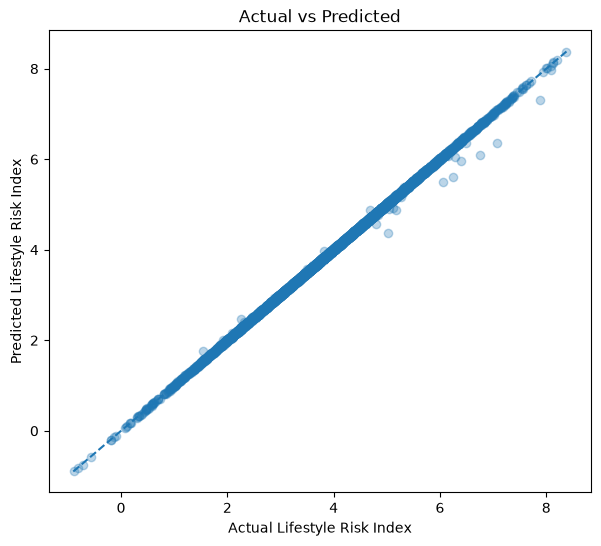

In [46]:
import matplotlib.pyplot as plt

# 실제값과 예측값 시각화
#
# 테스트 데이터의 실제 Lifestyle_Risk_Index와
# Linear Regression이 예측한 값을 산점도로 비교

plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    y_test_pred_linear,
    alpha=0.3
)

# 실제값 = 예측값인 기준선
min_value = min(y_test.min(), y_test_pred_linear.min())
max_value = max(y_test.max(), y_test_pred_linear.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Lifestyle Risk Index")
plt.ylabel("Predicted Lifestyle Risk Index")
plt.title("Actual vs Predicted")

plt.show()